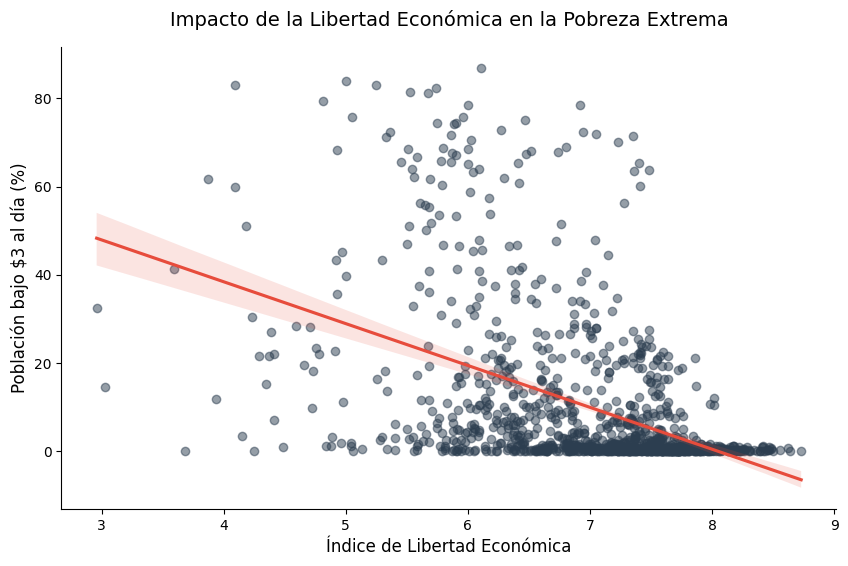

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_pov = pd.read_csv('share-of-population-living-in-extreme-poverty.csv')
df_efw = pd.read_csv('efw_cc.csv')

df_pov['Country'] = df_pov['Country'].str.replace(' \(urban\)', '', regex=True)

df_efw = df_efw.rename(columns={'countries': 'Country', 'year': 'Year'})
df_merged = pd.merge(df_pov, df_efw, on=['Country', 'Year'], how='inner')

plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_merged, 
    x='ECONOMIC FREEDOM', 
    y='Share below $3 a day',
    scatter_kws={'alpha':0.5, 'color':'#2c3e50'},
    line_kws={'color':'#e74c3c'}
)
plt.title('Impacto de la Libertad Económica en la Pobreza Extrema', fontsize=14, pad=15)
plt.xlabel('Índice de Libertad Económica', fontsize=12)
plt.ylabel('Población bajo $3 al día (%)', fontsize=12)
sns.despine()
plt.show()

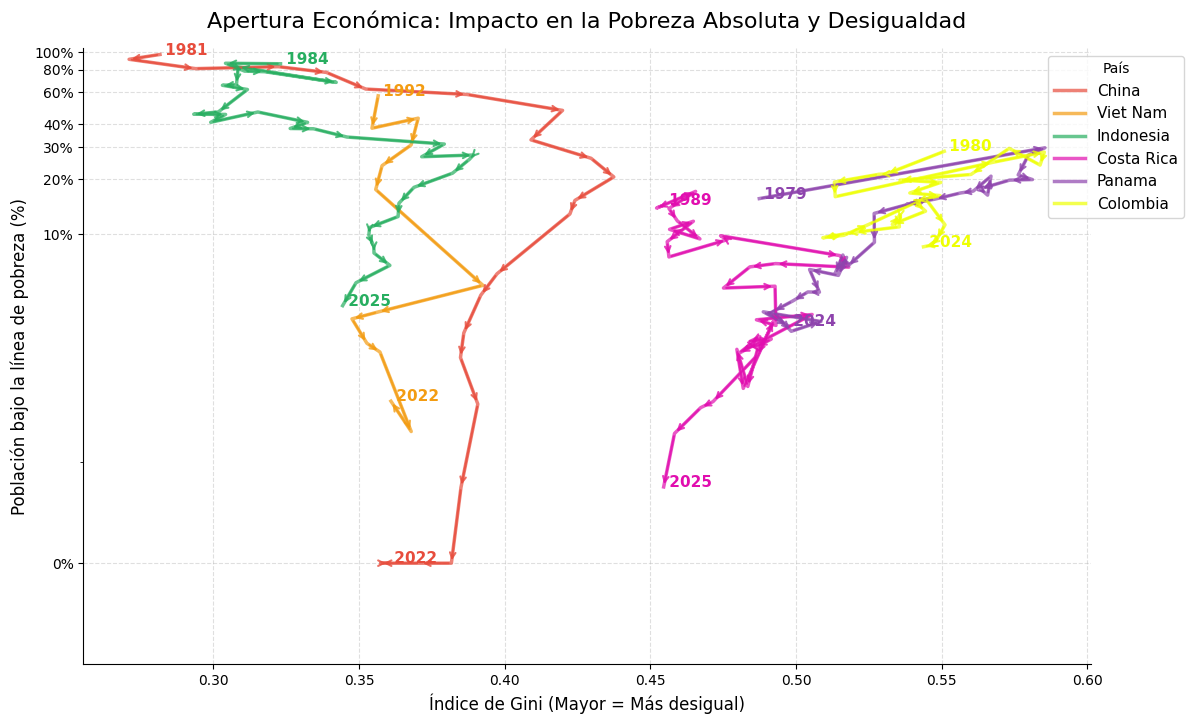

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_pip = pd.read_csv('pip.csv')

df_pip = df_pip.drop_duplicates(subset=['country_name', 'reporting_year'])
df_pip['headcount_pct'] = df_pip['headcount'] * 100
df_pip = df_pip[~((df_pip['country_name'] == 'Costa Rica') & (df_pip['reporting_year'] < 1989))]
paises_objetivo = ['China', 'Viet Nam', 'Indonesia', 'Costa Rica', 'Panama', 'Colombia']

df_trayectorias = df_pip[df_pip['country_name'].isin(paises_objetivo)].sort_values(['country_name', 'reporting_year'])

plt.figure(figsize=(13, 8))
colores = {
    'China': '#e74c3c',      
    'Viet Nam': '#f39c12',    
    'Indonesia': '#27ae60',  
    'Costa Rica': "#e10eaf", 
    'Panama': '#8e44ad',
    'Colombia': "#eeff03"
}

for pais in paises_objetivo:
    datos_pais = df_trayectorias[df_trayectorias['country_name'] == pais].dropna(subset=['gini', 'headcount_pct'])
    
    if datos_pais.empty:
        continue
        
    x = datos_pais['gini'].values
    y = datos_pais['headcount_pct'].values
    anios = datos_pais['reporting_year'].values
    
    plt.plot(x, y, color=colores[pais], linewidth=2.5, alpha=0.7, label=pais)
    
    for i in range(len(x)-1):
        plt.annotate('', xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                     arrowprops=dict(arrowstyle="->", color=colores[pais], lw=1.5, alpha=0.8))
    
    plt.text(x[0], y[0], f" {int(anios[0])}", fontsize=11, weight='bold', color=colores[pais])
    plt.text(x[-1], y[-1], f" {int(anios[-1])}", fontsize=11, weight='bold', color=colores[pais])

plt.yscale('symlog', linthresh=2.0)
plt.yticks([0, 10, 20, 30, 40, 60, 80, 100], ['0%', '10%', '20%', '30%', '40%', '60%', '80%', '100%'])
plt.ylim(-1, 105)

plt.title('Apertura Económica: Impacto en la Pobreza Absoluta y Desigualdad', fontsize=16, pad=15)
plt.xlabel('Índice de Gini (Mayor = Más desigual)', fontsize=12)
plt.ylabel('Población bajo la línea de pobreza (%)', fontsize=12)
plt.legend(title='País', loc='upper right', fontsize=11, bbox_to_anchor=(1.15, 1))
plt.grid(True, linestyle='--', alpha=0.4)
sns.despine()
plt.show()